In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
import os

print(os.getcwd())

d:\Pendrive\VSCode\Bioinformatics\notebooks


In [4]:
counts = pd.read_csv(
    "../data/raw/GSE60424_GEOSubmit_FC1to11_normalized_counts.txt",
    sep="\t"
)

In [5]:
counts.head()

,genenames,lib221,lib222,lib223,lib224,lib225,lib226,lib227,lib228,lib229,...,lib346,lib347,lib348,lib349,lib350,lib351,lib352,lib353,lib354,lib355
0,ENSG00000000003,1,0,1,1,1,0,0,0,2,...,1,0,1,0,0,0,1,1,0,0
1,ENSG00000000005,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ENSG00000000419,23,22,25,28,25,41,18,12,14,...,28,19,35,37,25,17,22,25,25,30
3,ENSG00000000457,11,11,14,17,11,32,9,24,19,...,18,13,15,26,5,23,17,15,14,14
4,ENSG00000000460,3,3,3,3,2,4,5,9,4,...,11,9,5,4,7,12,8,8,11,5


In [6]:
counts.columns

Index(['genenames', 'lib221', 'lib222', 'lib223', 'lib224', 'lib225', 'lib226',
       'lib227', 'lib228', 'lib229',
       ...
       'lib346', 'lib347', 'lib348', 'lib349', 'lib350', 'lib351', 'lib352',
       'lib353', 'lib354', 'lib355'],
      dtype='str', length=135)

In [7]:
counts.info()

<class 'pandas.DataFrame'>
RangeIndex: 50045 entries, 0 to 50044
Columns: 135 entries, genenames to lib355
dtypes: int64(134), str(1)
memory usage: 51.5 MB


In [8]:
counts.describe()

,lib221,lib222,lib223,lib224,lib225,lib226,lib227,lib228,lib229,lib230,...,lib346,lib347,lib348,lib349,lib350,lib351,lib352,lib353,lib354,lib355
count,50045.000000,50045.000000,50045.000000,50045.000000,50045.000000,50045.000000,50045.000000,50045.000000,50045.000000,50045.000000,...,50045.000000,50045.000000,50045.00000,50045.000000,50045.000000,50045.000000,50045.000000,50045.000000,50045.000000,50045.000000
mean,22.609811,20.416645,22.204296,18.568568,18.031592,35.974503,23.953202,18.340034,16.302388,18.206374,...,17.667060,13.903267,19.96683,30.438186,20.827076,15.643201,14.999520,16.880827,17.561734,19.049336
std,202.076893,163.340574,189.145843,122.615153,125.902534,337.264033,208.023134,157.914431,122.106600,145.960418,...,150.076741,91.380062,161.21924,297.109314,164.726211,148.432453,109.394214,129.482066,129.682870,147.550731
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,2.000000,2.000000,2.000000,2.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,2.000000,1.000000,2.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
max,25656.000000,17215.000000,20526.000000,9921.000000,11774.000000,20990.000000,17443.000000,13702.000000,8783.000000,11408.000000,...,13108.000000,7567.000000,17584.00000,22082.000000,12784.000000,13217.000000,8355.000000,10320.000000,10430.000000,16233.000000


In [9]:
counts.isnull().sum()

genenames    0
lib221       0
lib222       0
lib223       0
lib224       0
            ..
lib351       0
lib352       0
lib353       0
lib354       0
lib355       0
Length: 135, dtype: int64

In [10]:
counts.shape

(50045, 135)

In [11]:
genes = counts['genenames']

expression = counts.drop(columns='genenames')

# Plot Expression Distribution

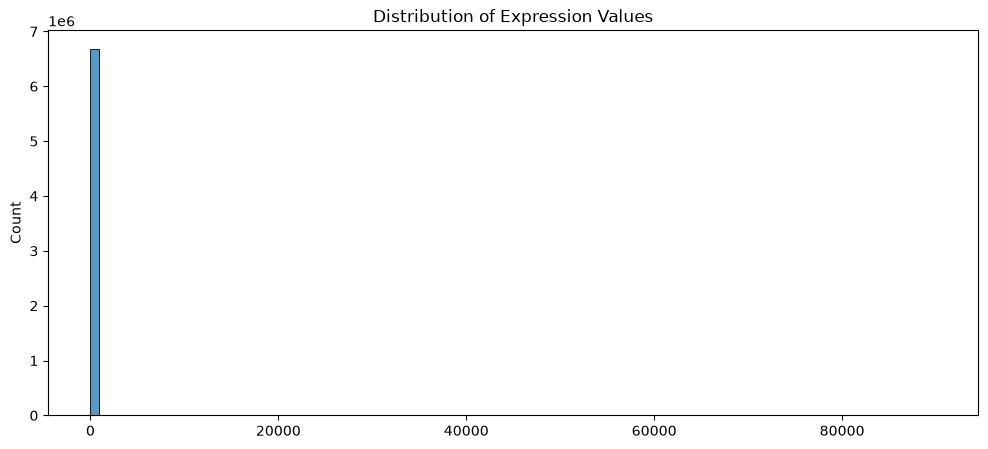

In [12]:
plt.figure(figsize=(12,5))

sns.histplot(expression.values.flatten(), bins=100)

plt.title("Distribution of Expression Values")

plt.show()

In [13]:
plt.savefig("../figures/expression_distribution.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [14]:
corr = expression.corr()

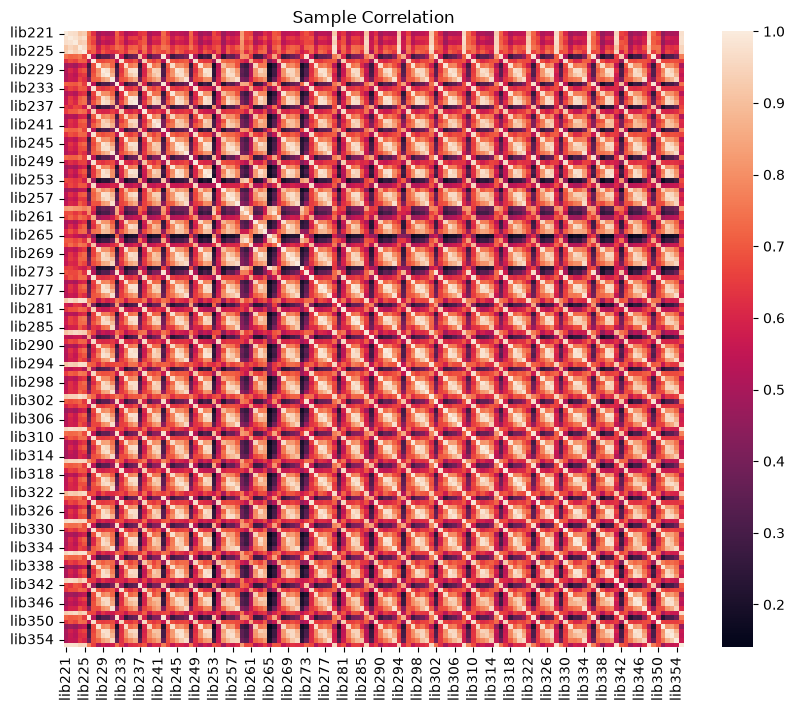

In [15]:
plt.figure(figsize=(10,8))

sns.heatmap(corr)

plt.title("Sample Correlation")

plt.show()

# PCA

In [16]:
X = expression.T

In [17]:
X_scaled = StandardScaler().fit_transform(X)

In [18]:
pca = PCA(n_components=2)

pcs = pca.fit_transform(X_scaled)

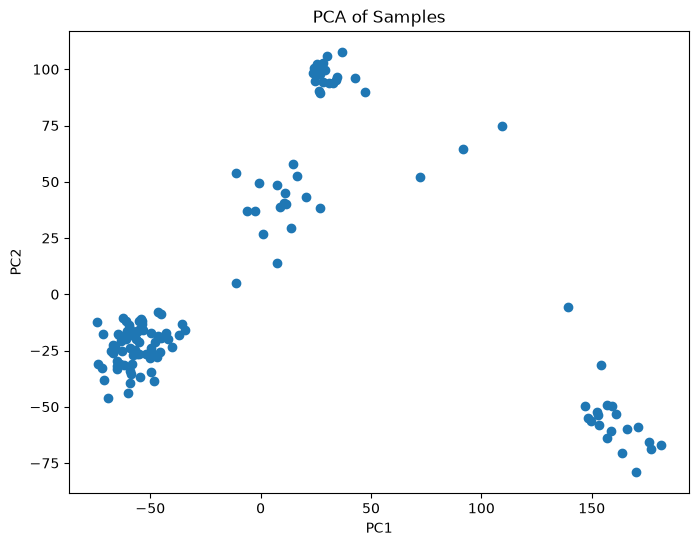

<Figure size 640x480 with 0 Axes>

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    pcs[:,0],
    pcs[:,1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA of Samples")

plt.show()
plt.savefig("../figures/PCA_distribution.png", dpi=300)

In [28]:
metadata = pd.read_csv(
    "../data/metadata/GSE60424_series_matrix.txt",
    sep="\t",
    header=None
)

ParserError: Error tokenizing data. C error: Expected 2 fields in line 38, saw 135


In [29]:
with open("../data/metadata/GSE60424_series_matrix.txt", "r", encoding="utf-8") as f:
    for i in range(50):
        print(f.readline().strip())

!Series_title	"Next generation sequencing of human immune cell subsets across diseases"
!Series_geo_accession	"GSE60424"
!Series_status	"Public on Jan 06 2015"
!Series_submission_date	"Aug 14 2014"
!Series_last_update_date	"Jan 04 2024"
!Series_pubmed_id	"25314013"
!Series_summary	"This study compared whole transcriptome signatures of 6 immune cell subsets and whole blood from patients with an array of immune-associated diseases. Fresh blood samples were collected from healthy subjects and subjects diagnosed type 1 diabetes, amyotrophic lateral sclerosis, and sepsis, as well as multiple sclerosis patients before and 24 hours after the first treatment with IFN-beta. At the time of blood draw, an aliquot of whole blood was collected into a Tempus tube (Invitrogen), while the remainder of the primary fresh blood sample was processed to highly pure populations of neutrophils, monocytes, B cells, CD4 T cells, CD8 T cells, and natural killer cells. RNA was extracted from each of these cell s

In [25]:
metadata.head()

,ID_REF,GSM1479433,GSM1479434,GSM1479435,GSM1479436,GSM1479437,GSM1479438,GSM1479439,GSM1479440,GSM1479441,...,GSM1479557,GSM1479558,GSM1479559,GSM1479560,GSM1479561,GSM1479562,GSM1479563,GSM1479564,GSM1479565,GSM1479566


In [30]:
with open("../data/metadata/GSE60424_series_matrix.txt", "r", encoding="utf-8") as f:
    for i in range(60):
        print(f"{i+1}: {f.readline().strip()}")

1: !Series_title	"Next generation sequencing of human immune cell subsets across diseases"
2: !Series_geo_accession	"GSE60424"
3: !Series_status	"Public on Jan 06 2015"
4: !Series_submission_date	"Aug 14 2014"
5: !Series_last_update_date	"Jan 04 2024"
6: !Series_pubmed_id	"25314013"
7: !Series_summary	"This study compared whole transcriptome signatures of 6 immune cell subsets and whole blood from patients with an array of immune-associated diseases. Fresh blood samples were collected from healthy subjects and subjects diagnosed type 1 diabetes, amyotrophic lateral sclerosis, and sepsis, as well as multiple sclerosis patients before and 24 hours after the first treatment with IFN-beta. At the time of blood draw, an aliquot of whole blood was collected into a Tempus tube (Invitrogen), while the remainder of the primary fresh blood sample was processed to highly pure populations of neutrophils, monocytes, B cells, CD4 T cells, CD8 T cells, and natural killer cells. RNA was extracted from

In [31]:
sample_info = []

with open("../data/metadata/GSE60424_series_matrix.txt", "r", encoding="utf-8") as f:
    for line in f:
        if line.startswith("!Sample"):
            sample_info.append(line.strip().split("\t"))

sample_df = pd.DataFrame(sample_info)

sample_df.head()

,0,1,2,3,4,5,6,7,8,9,...,125,126,127,128,129,130,131,132,133,134
0,!Sample_title,"""lib221""","""lib222""","""lib223""","""lib224""","""lib225""","""lib226""","""lib227""","""lib228""","""lib229""",...,"""lib346""","""lib347""","""lib348""","""lib349""","""lib350""","""lib351""","""lib352""","""lib353""","""lib354""","""lib355"""
1,!Sample_geo_accession,"""GSM1479433""","""GSM1479434""","""GSM1479435""","""GSM1479436""","""GSM1479437""","""GSM1479438""","""GSM1479439""","""GSM1479440""","""GSM1479441""",...,"""GSM1479557""","""GSM1479558""","""GSM1479559""","""GSM1479560""","""GSM1479561""","""GSM1479562""","""GSM1479563""","""GSM1479564""","""GSM1479565""","""GSM1479566"""
2,!Sample_status,"""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""",...,"""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015"""
3,!Sample_submission_date,"""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""",...,"""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014"""
4,!Sample_last_update_date,"""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""",...,"""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024"""


In [32]:
sample_df.iloc[:,0]


0                       !Sample_title
1               !Sample_geo_accession
2                      !Sample_status
3             !Sample_submission_date
4            !Sample_last_update_date
5                        !Sample_type
6               !Sample_channel_count
7             !Sample_source_name_ch1
8                !Sample_organism_ch1
9         !Sample_characteristics_ch1
10        !Sample_characteristics_ch1
11        !Sample_characteristics_ch1
12        !Sample_characteristics_ch1
13        !Sample_characteristics_ch1
14        !Sample_characteristics_ch1
15        !Sample_characteristics_ch1
16        !Sample_characteristics_ch1
17        !Sample_characteristics_ch1
18        !Sample_characteristics_ch1
19        !Sample_characteristics_ch1
20        !Sample_characteristics_ch1
21        !Sample_characteristics_ch1
22        !Sample_characteristics_ch1
23        !Sample_characteristics_ch1
24               !Sample_molecule_ch1
25       !Sample_extract_protocol_ch1
26          

In [33]:
sample_df.to_csv(
    "../data/processed/sample_metadata.csv",
    index=False
)

In [34]:
for row in sample_df.iloc[:,0]:
    print(row)

!Sample_title
!Sample_geo_accession
!Sample_status
!Sample_submission_date
!Sample_last_update_date
!Sample_type
!Sample_channel_count
!Sample_source_name_ch1
!Sample_organism_ch1
!Sample_characteristics_ch1
!Sample_characteristics_ch1
!Sample_characteristics_ch1
!Sample_characteristics_ch1
!Sample_characteristics_ch1
!Sample_characteristics_ch1
!Sample_characteristics_ch1
!Sample_characteristics_ch1
!Sample_characteristics_ch1
!Sample_characteristics_ch1
!Sample_characteristics_ch1
!Sample_characteristics_ch1
!Sample_characteristics_ch1
!Sample_characteristics_ch1
!Sample_characteristics_ch1
!Sample_molecule_ch1
!Sample_extract_protocol_ch1
!Sample_taxid_ch1
!Sample_data_processing
!Sample_data_processing
!Sample_data_processing
!Sample_data_processing
!Sample_data_processing
!Sample_data_processing
!Sample_platform_id
!Sample_contact_name
!Sample_contact_email
!Sample_contact_institute
!Sample_contact_address
!Sample_contact_city
!Sample_contact_state
!Sample_contact_zip/postal_code


In [36]:
sample_df

,0,1,2,3,4,5,6,7,8,9,...,125,126,127,128,129,130,131,132,133,134
0,!Sample_title,"""lib221""","""lib222""","""lib223""","""lib224""","""lib225""","""lib226""","""lib227""","""lib228""","""lib229""",...,"""lib346""","""lib347""","""lib348""","""lib349""","""lib350""","""lib351""","""lib352""","""lib353""","""lib354""","""lib355"""
1,!Sample_geo_accession,"""GSM1479433""","""GSM1479434""","""GSM1479435""","""GSM1479436""","""GSM1479437""","""GSM1479438""","""GSM1479439""","""GSM1479440""","""GSM1479441""",...,"""GSM1479557""","""GSM1479558""","""GSM1479559""","""GSM1479560""","""GSM1479561""","""GSM1479562""","""GSM1479563""","""GSM1479564""","""GSM1479565""","""GSM1479566"""
2,!Sample_status,"""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""",...,"""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015""","""Public on Jan 06 2015"""
3,!Sample_submission_date,"""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""",...,"""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014""","""Aug 14 2014"""
4,!Sample_last_update_date,"""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""",...,"""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024""","""Jan 04 2024"""
5,!Sample_type,"""SRA""","""SRA""","""SRA""","""SRA""","""SRA""","""SRA""","""SRA""","""SRA""","""SRA""",...,"""SRA""","""SRA""","""SRA""","""SRA""","""SRA""","""SRA""","""SRA""","""SRA""","""SRA""","""SRA"""
6,!Sample_channel_count,"""1""","""1""","""1""","""1""","""1""","""1""","""1""","""1""","""1""",...,"""1""","""1""","""1""","""1""","""1""","""1""","""1""","""1""","""1""","""1"""
7,!Sample_source_name_ch1,"""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""",...,"""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood"""
8,!Sample_organism_ch1,"""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""",...,"""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens""","""Homo sapiens"""
9,!Sample_characteristics_ch1,"""age: 32""","""age: 52""","""age: 52""","""age: 24""","""age: 27""","""age: 32""","""age: 32""","""age: 32""","""age: 32""",...,"""age: 35""","""age: 35""","""age: 35""","""age: --""","""age: --""","""age: --""","""age: --""","""age: --""","""age: --""","""age: --"""


In [37]:
sample_df[sample_df[0].str.contains("disease", case=False, na=False)]

,0,1,2,3,4,5,6,7,8,9,...,125,126,127,128,129,130,131,132,133,134


In [38]:
sample_df[sample_df[0].str.contains("cell", case=False, na=False)]

,0,1,2,3,4,5,6,7,8,9,...,125,126,127,128,129,130,131,132,133,134


In [39]:
sample_df[sample_df[0].str.contains("source", case=False, na=False)]

,0,1,2,3,4,5,6,7,8,9,...,125,126,127,128,129,130,131,132,133,134
7,!Sample_source_name_ch1,"""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""",...,"""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood""","""Whole Blood"""
45,!Sample_library_source,"""transcriptomic""","""transcriptomic""","""transcriptomic""","""transcriptomic""","""transcriptomic""","""transcriptomic""","""transcriptomic""","""transcriptomic""","""transcriptomic""",...,"""transcriptomic""","""transcriptomic""","""transcriptomic""","""transcriptomic""","""transcriptomic""","""transcriptomic""","""transcriptomic""","""transcriptomic""","""transcriptomic""","""transcriptomic"""


In [40]:
expression.describe().T

,count,mean,std,min,25%,50%,75%,max
lib221,50045.0,22.609811,202.076893,0.0,0.0,0.0,2.0,25656.0
lib222,50045.0,20.416645,163.340574,0.0,0.0,0.0,2.0,17215.0
lib223,50045.0,22.204296,189.145843,0.0,0.0,0.0,2.0,20526.0
lib224,50045.0,18.568568,122.615153,0.0,0.0,0.0,2.0,9921.0
lib225,50045.0,18.031592,125.902534,0.0,0.0,0.0,2.0,11774.0
...,...,...,...,...,...,...,...,...
lib351,50045.0,15.643201,148.432453,0.0,0.0,0.0,1.0,13217.0
lib352,50045.0,14.999520,109.394214,0.0,0.0,0.0,1.0,8355.0
lib353,50045.0,16.880827,129.482066,0.0,0.0,0.0,1.0,10320.0
lib354,50045.0,17.561734,129.682870,0.0,0.0,0.0,1.0,10430.0


In [41]:
sample_df[0].unique()

<StringArray>
[                  '!Sample_title',           '!Sample_geo_accession',
                  '!Sample_status',         '!Sample_submission_date',
        '!Sample_last_update_date',                    '!Sample_type',
           '!Sample_channel_count',         '!Sample_source_name_ch1',
            '!Sample_organism_ch1',     '!Sample_characteristics_ch1',
            '!Sample_molecule_ch1',    '!Sample_extract_protocol_ch1',
               '!Sample_taxid_ch1',         '!Sample_data_processing',
             '!Sample_platform_id',            '!Sample_contact_name',
           '!Sample_contact_email',       '!Sample_contact_institute',
         '!Sample_contact_address',            '!Sample_contact_city',
           '!Sample_contact_state', '!Sample_contact_zip/postal_code',
         '!Sample_contact_country',          '!Sample_data_row_count',
        '!Sample_instrument_model',       '!Sample_library_selection',
          '!Sample_library_source',        '!Sample_library_str

In [42]:
sample_df[sample_df[0] == "!Sample_characteristics_ch1"]

,0,1,2,3,4,5,6,7,8,9,...,125,126,127,128,129,130,131,132,133,134
9,!Sample_characteristics_ch1,"""age: 32""","""age: 52""","""age: 52""","""age: 24""","""age: 27""","""age: 32""","""age: 32""","""age: 32""","""age: 32""",...,"""age: 35""","""age: 35""","""age: 35""","""age: --""","""age: --""","""age: --""","""age: --""","""age: --""","""age: --""","""age: --"""
10,!Sample_characteristics_ch1,"""cellcount: --""","""cellcount: --""","""cellcount: --""","""cellcount: --""","""cellcount: --""","""cellcount: 14737500""","""cellcount: 2000000""","""cellcount: 1012333""","""cellcount: 1071990""",...,"""cellcount: 1352936""","""cellcount: 310438""","""cellcount: --""","""cellcount: 12375000""","""cellcount: 2000000""","""cellcount: 2000000""","""cellcount: 2000000""","""cellcount: 2000000""","""cellcount: 1708523""","""cellcount: --"""
11,!Sample_characteristics_ch1,"""celltype: Whole Blood""","""celltype: Whole Blood""","""celltype: Whole Blood""","""celltype: Whole Blood""","""celltype: Whole Blood""","""celltype: Neutrophils""","""celltype: Monocytes""","""celltype: B-cells""","""celltype: CD4""",...,"""celltype: CD8""","""celltype: NK""","""celltype: Whole Blood""","""celltype: Neutrophils""","""celltype: Monocytes""","""celltype: B-cells""","""celltype: CD4""","""celltype: CD8""","""celltype: NK""","""celltype: Whole Blood"""
12,!Sample_characteristics_ch1,"""collectiondate: June 26 2012""","""collectiondate: May 21 2012""","""collectiondate: May 22 2012""","""collectiondate: May 23 2012""","""collectiondate: June 6 2012""","""collectiondate: June 26 2012""","""collectiondate: June 26 2012""","""collectiondate: June 26 2012""","""collectiondate: June 26 2012""",...,"""collectiondate: August 24 2012""","""collectiondate: August 24 2012""","""collectiondate: August 24 2012""","""collectiondate: September 12 2012""","""collectiondate: September 12 2012""","""collectiondate: September 12 2012""","""collectiondate: September 12 2012""","""collectiondate: September 12 2012""","""collectiondate: September 12 2012""","""collectiondate: September 12 2012"""
13,!Sample_characteristics_ch1,"""diseasestatus: Healthy Control""","""diseasestatus: MS pretreatment""","""diseasestatus: MS posttreatment""","""diseasestatus: Type 1 Diabetes""","""diseasestatus: Type 1 Diabetes""","""diseasestatus: Healthy Control""","""diseasestatus: Healthy Control""","""diseasestatus: Healthy Control""","""diseasestatus: Healthy Control""",...,"""diseasestatus: MS posttreatment""","""diseasestatus: MS posttreatment""","""diseasestatus: MS posttreatment""","""diseasestatus: ALS""","""diseasestatus: ALS""","""diseasestatus: ALS""","""diseasestatus: ALS""","""diseasestatus: ALS""","""diseasestatus: ALS""","""diseasestatus: ALS"""
14,!Sample_characteristics_ch1,"""donorid: 44""","""donorid: 31""","""donorid: 33""","""donorid: 34""","""donorid: 37""","""donorid: 44""","""donorid: 44""","""donorid: 44""","""donorid: 44""",...,"""donorid: 56""","""donorid: 56""","""donorid: 56""","""donorid: 58""","""donorid: 58""","""donorid: 58""","""donorid: 58""","""donorid: 58""","""donorid: 58""","""donorid: 58"""
15,!Sample_characteristics_ch1,"""gender: F""","""gender: F""","""gender: F""","""gender: F""","""gender: F""","""gender: F""","""gender: F""","""gender: F""","""gender: F""",...,"""gender: F""","""gender: F""","""gender: F""","""gender: ""","""gender: ""","""gender: ""","""gender: ""","""gender: ""","""gender: ""","""gender: """
16,!Sample_characteristics_ch1,"""index: 21""","""index: 2""","""index: 9""","""index: 13""","""index: 23""","""index: 5""","""index: 23""","""index: 6""","""index: 25""",...,"""index: 23""","""index: 9""","""index: 19""","""index: 12""","""index: 8""","""index: 11""","""index: 5""","""index: 20""","""index: 25""","""index: 10"""
17,!Sample_characteristics_ch1,"""race: Hispanic""","""race: White""","""race: White""","""race: White""","""race: White""","""race: Hispanic""","""race: Hispanic""","""race: Hispanic""","""race: Hispanic""",...,"""rac

In [43]:
metadata = sample_df.set_index(0).T
metadata.head()

,!Sample_title,!Sample_geo_accession,!Sample_status,!Sample_submission_date,!Sample_last_update_date,!Sample_type,!Sample_channel_count,!Sample_source_name_ch1,!Sample_organism_ch1,!Sample_characteristics_ch1,...,!Sample_contact_zip/postal_code,!Sample_contact_country,!Sample_data_row_count,!Sample_instrument_model,!Sample_library_selection,!Sample_library_source,!Sample_library_strategy,!Sample_relation,!Sample_relation,!Sample_supplementary_file_1
1,"""lib221""","""GSM1479433""","""Public on Jan 06 2015""","""Aug 14 2014""","""Jan 04 2024""","""SRA""","""1""","""Whole Blood""","""Homo sapiens""","""age: 32""",...,"""98101""","""USA""","""0""","""Illumina HiScanSQ""","""cDNA""","""transcriptomic""","""RNA-Seq""","""BioSample: https://www.ncbi.nlm.nih.gov/biosa...","""SRA: https://www.ncbi.nlm.nih.gov/sra?term=SR...","""NONE"""
2,"""lib222""","""GSM1479434""","""Public on Jan 06 2015""","""Aug 14 2014""","""Jan 04 2024""","""SRA""","""1""","""Whole Blood""","""Homo sapiens""","""age: 52""",...,"""98101""","""USA""","""0""","""Illumina HiScanSQ""","""cDNA""","""transcriptomic""","""RNA-Seq""","""BioSample: https://www.ncbi.nlm.nih.gov/biosa...","""SRA: https://www.ncbi.nlm.nih.gov/sra?term=SR...","""NONE"""
3,"""lib223""","""GSM1479435""","""Public on Jan 06 2015""","""Aug 14 2014""","""Jan 04 2024""","""SRA""","""1""","""Whole Blood""","""Homo sapiens""","""age: 52""",...,"""98101""","""USA""","""0""","""Illumina HiScanSQ""","""cDNA""","""transcriptomic""","""RNA-Seq""","""BioSample: https://www.ncbi.nlm.nih.gov/biosa...","""SRA: https://www.ncbi.nlm.nih.gov/sra?term=SR...","""NONE"""
4,"""lib224""","""GSM1479436""","""Public on Jan 06 2015""","""Aug 14 2014""","""Jan 04 2024""","""SRA""","""1""","""Whole Blood""","""Homo sapiens""","""age: 24""",...,"""98101""","""USA""","""0""","""Illumina HiScanSQ""","""cDNA""","""transcriptomic""","""RNA-Seq""","""BioSample: https://www.ncbi.nlm.nih.gov/biosa...","""SRA: https://www.ncbi.nlm.nih.gov/sra?term=SR...","""NONE"""
5,"""lib225""","""GSM1479437""","""Public on Jan 06 2015""","""Aug 14 2014""","""Jan 04 2024""","""SRA""","""1""","""Whole Blood""","""Homo sapiens""","""age: 27""",...,"""98101""","""USA""","""0""","""Illumina HiScanSQ""","""cDNA""","""transcriptomic""","""RNA-Seq""","""BioSample: https://www.ncbi.nlm.nih.gov/biosa...","""SRA: https://www.ncbi.nlm.nih.gov/sra?term=SR...","""NONE"""


In [44]:
metadata.columns.tolist()

['!Sample_title',
 '!Sample_geo_accession',
 '!Sample_status',
 '!Sample_submission_date',
 '!Sample_last_update_date',
 '!Sample_type',
 '!Sample_channel_count',
 '!Sample_source_name_ch1',
 '!Sample_organism_ch1',
 '!Sample_characteristics_ch1',
 '!Sample_characteristics_ch1',
 '!Sample_characteristics_ch1',
 '!Sample_characteristics_ch1',
 '!Sample_characteristics_ch1',
 '!Sample_characteristics_ch1',
 '!Sample_characteristics_ch1',
 '!Sample_characteristics_ch1',
 '!Sample_characteristics_ch1',
 '!Sample_characteristics_ch1',
 '!Sample_characteristics_ch1',
 '!Sample_characteristics_ch1',
 '!Sample_characteristics_ch1',
 '!Sample_characteristics_ch1',
 '!Sample_characteristics_ch1',
 '!Sample_molecule_ch1',
 '!Sample_extract_protocol_ch1',
 '!Sample_taxid_ch1',
 '!Sample_data_processing',
 '!Sample_data_processing',
 '!Sample_data_processing',
 '!Sample_data_processing',
 '!Sample_data_processing',
 '!Sample_data_processing',
 '!Sample_platform_id',
 '!Sample_contact_name',
 '!Samp

In [45]:
metadata.filter(like="disease", axis=1)

""
1
2
3
4
5
...
130
131
132
133


In [48]:
disease_status = sample_df.iloc[13, 1:]

disease_status.head()

1     "diseasestatus: Healthy Control"
2     "diseasestatus: MS pretreatment"
3    "diseasestatus: MS posttreatment"
4     "diseasestatus: Type 1 Diabetes"
5     "diseasestatus: Type 1 Diabetes"
Name: 13, dtype: str

In [ ]:
disease_status = (
    disease_status
    .str.replace('"', '', regex=False)
    .str.replace("diseasestatus: ", "", regex=False)
)

disease_status.head()


13
Healthy Control     28
Type 1 Diabetes     26
ALS                 21
MS posttreatment    20
Sepsis              20
MS pretreatment     19
Name: count, dtype: int64

In [50]:
cell_type = sample_df.iloc[11,1:]

cell_type = (
    cell_type
    .str.replace('"','',regex=False)
    .str.replace("celltype: ","",regex=False)
)

cell_type.value_counts()

11
Whole Blood    20
Neutrophils    20
Monocytes      20
B-cells        20
CD4            20
CD8            20
NK             14
Name: count, dtype: int64

In [52]:
meta_data = pd.DataFrame({
    "sample": sample_df.iloc[0,1:].values,
    "geo_accession": sample_df.iloc[1,1:].values,
    "cell_type": cell_type.values,
    "disease": disease_status.values
})

meta_data.head()

,sample,geo_accession,cell_type,disease
0,"""lib221""","""GSM1479433""",Whole Blood,Healthy Control
1,"""lib222""","""GSM1479434""",Whole Blood,MS pretreatment
2,"""lib223""","""GSM1479435""",Whole Blood,MS posttreatment
3,"""lib224""","""GSM1479436""",Whole Blood,Type 1 Diabetes
4,"""lib225""","""GSM1479437""",Whole Blood,Type 1 Diabetes


In [53]:
meta_data.to_csv(
    "../data/processed/sample_metadata_clean.csv",
    index=False
)

# How many samples belong to each disease?

In [54]:
disease_status.value_counts()

13
Healthy Control     28
Type 1 Diabetes     26
ALS                 21
MS posttreatment    20
Sepsis              20
MS pretreatment     19
Name: count, dtype: int64

# How many samples are there for each cell type?

In [55]:
cell_type.value_counts()

11
Whole Blood    20
Neutrophils    20
Monocytes      20
B-cells        20
CD4            20
CD8            20
NK             14
Name: count, dtype: int64

# Count disease × cell type combinations

In [56]:
pd.crosstab(
    meta_data["cell_type"],
    meta_data["disease"]
)

disease,ALS,Healthy Control,MS posttreatment,MS pretreatment,Sepsis,Type 1 Diabetes
cell_type,,,,,,
B-cells,3,4,3,3,3,4
CD4,3,4,3,3,3,4
CD8,3,4,3,3,3,4
Monocytes,3,4,3,3,3,4
NK,3,4,2,1,2,2
Neutrophils,3,4,3,3,3,4
Whole Blood,3,4,3,3,3,4


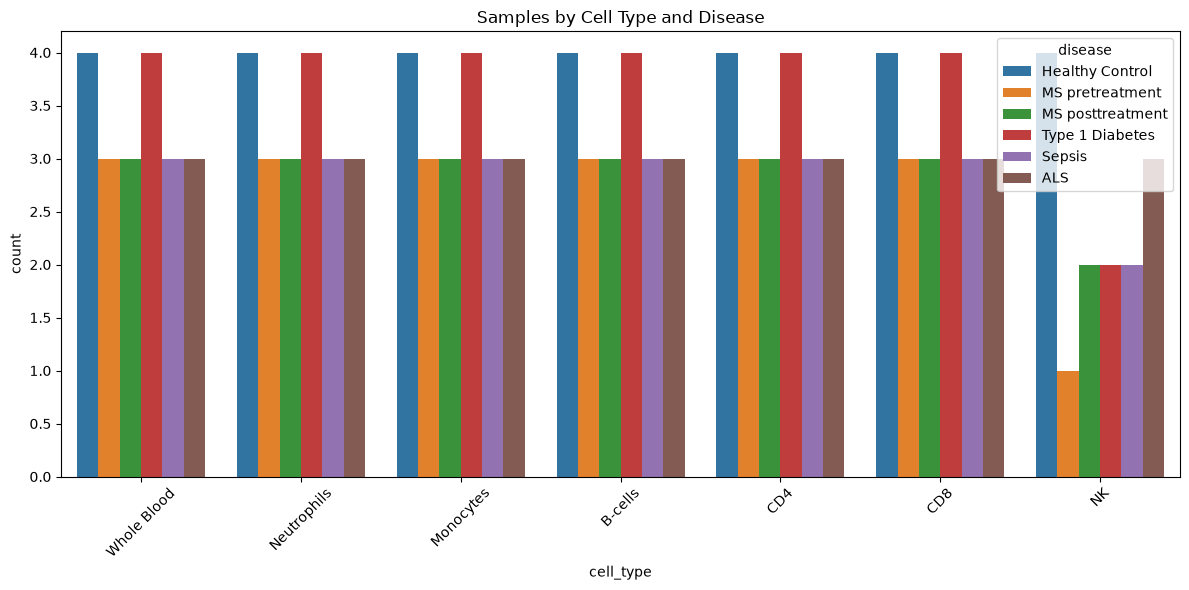

In [58]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=meta_data,
    x="cell_type",
    hue="disease"
)

plt.xticks(rotation=45)
plt.title("Samples by Cell Type and Disease")
plt.tight_layout()
plt.show()

In [79]:
cd4_metadata = meta_data[meta_data["cell_type"] == "CD4"]

cd4_metadata

,sample,geo_accession,cell_type,disease
8,lib229,"""GSM1479441""",CD4,Healthy Control
14,lib235,"""GSM1479447""",CD4,MS pretreatment
19,lib240,"""GSM1479452""",CD4,MS posttreatment
24,lib245,"""GSM1479457""",CD4,Type 1 Diabetes
30,lib251,"""GSM1479463""",CD4,Type 1 Diabetes
35,lib256,"""GSM1479468""",CD4,Sepsis
42,lib263,"""GSM1479475""",CD4,Sepsis
48,lib269,"""GSM1479481""",CD4,Sepsis
55,lib276,"""GSM1479488""",CD4,MS pretreatment
62,lib283,"""GSM1479495""",CD4,MS posttreatment


In [80]:
cd4_metadata = cd4_metadata[
    cd4_metadata["disease"].isin(
        ["Healthy Control", "MS pretreatment"]
    )
]

cd4_metadata

,sample,geo_accession,cell_type,disease
8,lib229,"""GSM1479441""",CD4,Healthy Control
14,lib235,"""GSM1479447""",CD4,MS pretreatment
55,lib276,"""GSM1479488""",CD4,MS pretreatment
69,lib291,"""GSM1479502""",CD4,Healthy Control
76,lib298,"""GSM1479509""",CD4,Healthy Control
90,lib312,"""GSM1479523""",CD4,Healthy Control
117,lib339,"""GSM1479550""",CD4,MS pretreatment


In [81]:
selected_samples = cd4_metadata["sample"].tolist()

selected_samples

['lib229', 'lib235', 'lib276', 'lib291', 'lib298', 'lib312', 'lib339']

In [82]:
# FIX: Remove the square brackets around expression.columns
exp = expression.columns

for i in selected_samples:
    if i not in exp:
        print(f"{i} NOT in exp")
    else:
        print(f"{i} in exp")

lib229 in exp
lib235 in exp
lib276 in exp
lib291 in exp
lib298 in exp
lib312 in exp
lib339 in exp


In [83]:
meta_data["sample"] = (
    meta_data["sample"]
    .str.strip()
    .str.replace('"', '', regex=False)
)

In [ ]:
expression_cd4 = expression[selected_samples]

expression_cd4.head()

,lib229,lib235,lib276,lib291,lib298,lib312,lib339
0,2,2,2,3,2,2,2
1,0,0,0,0,0,0,0
2,14,14,18,24,19,20,19
3,19,22,25,24,18,18,17
4,4,6,10,10,7,7,12


In [84]:
expression_cd4 = expression[selected_samples]

expression_cd4.head()

,lib229,lib235,lib276,lib291,lib298,lib312,lib339
0,2,2,2,3,2,2,2
1,0,0,0,0,0,0,0
2,14,14,18,24,19,20,19
3,19,22,25,24,18,18,17
4,4,6,10,10,7,7,12


In [85]:
expression_cd4.shape


(50045, 7)

In [86]:
expression_log = np.log2(expression_cd4 + 1)

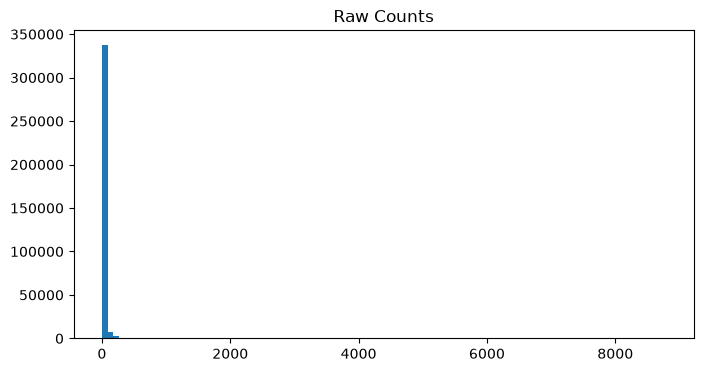

In [87]:
plt.figure(figsize=(8,4))

plt.hist(expression_cd4.values.flatten(), bins=100)

plt.title("Raw Counts")

plt.show()

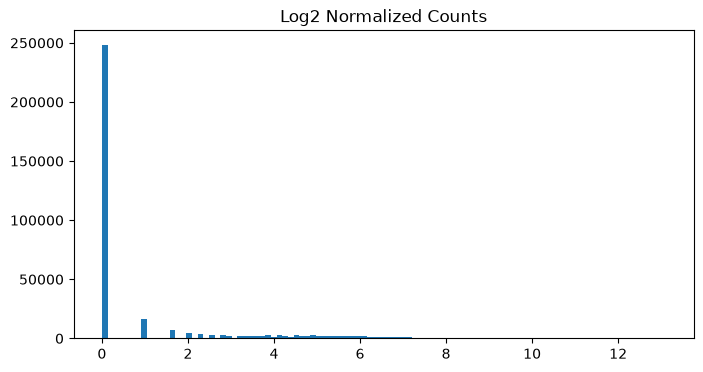

In [88]:
plt.figure(figsize=(8,4))

plt.hist(expression_log.values.flatten(), bins=100)

plt.title("Log2 Normalized Counts")

plt.show()

# Filter low-experssion genes

In [89]:
mask = (expression_cd4 > 5).sum(axis=1) >= 3

expression_filtered = expression_cd4[mask]

In [90]:
print("Original genes:", expression_cd4.shape[0])
print("Filtered genes:", expression_filtered.shape[0])

Original genes: 50045
Filtered genes: 9872


In [91]:
expression_filtered_log = np.log2(expression_filtered + 1)

In [92]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = expression_filtered_log.T

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

pcs = pca.fit_transform(X_scaled)

In [93]:
pca_df = pd.DataFrame({
    "PC1": pcs[:,0],
    "PC2": pcs[:,1],
    "Disease": cd4_metadata["disease"].values,
    "Sample": cd4_metadata["sample"].values
})

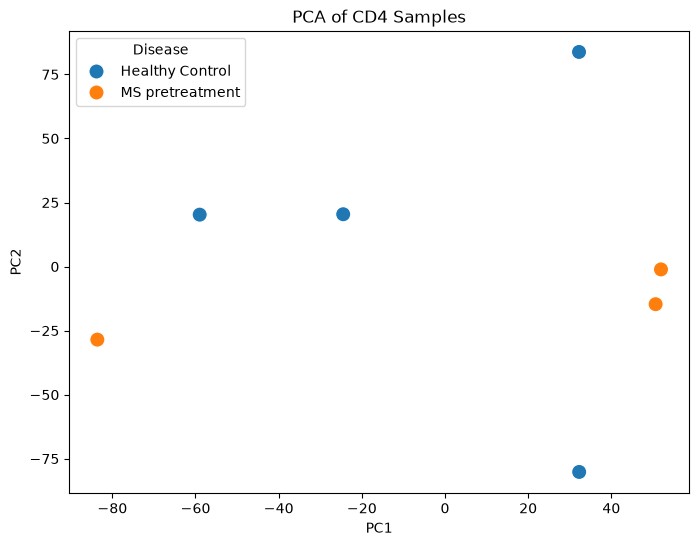

In [94]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Disease",
    s=120
)

plt.title("PCA of CD4 Samples")

plt.show()

In [101]:
comparison = meta_data[
    (meta_data["cell_type"] == "CD4") &
    (meta_data["disease"].isin(["Healthy Control", "MS pretreatment"]))
].copy()

comparison

,sample,geo_accession,cell_type,disease
8,lib229,"""GSM1479441""",CD4,Healthy Control
14,lib235,"""GSM1479447""",CD4,MS pretreatment
55,lib276,"""GSM1479488""",CD4,MS pretreatment
69,lib291,"""GSM1479502""",CD4,Healthy Control
76,lib298,"""GSM1479509""",CD4,Healthy Control
90,lib312,"""GSM1479523""",CD4,Healthy Control
117,lib339,"""GSM1479550""",CD4,MS pretreatment


In [102]:
comparison["disease"].value_counts()

disease
Healthy Control    4
MS pretreatment    3
Name: count, dtype: int64

In [103]:
expression.columns = expression.columns.str.strip().str.replace('"', '', regex=False)

comparison["sample"] = comparison["sample"].str.strip().str.replace('"', '', regex=False)

In [104]:
selected_samples = comparison["sample"].tolist()

expression_subset = expression.loc[:, selected_samples]

In [105]:
expression_subset.shape

(50045, 7)

# Log Transformation

In [106]:
expression_log = np.log2(expression_subset + 1)

In [107]:
healthy_samples = comparison.loc[
    comparison["disease"] == "Healthy Control",
    "sample"
].tolist()

ms_samples = comparison.loc[
    comparison["disease"] == "MS pretreatment",
    "sample"
].tolist()

In [108]:
healthy = expression_log[healthy_samples]

ms = expression_log[ms_samples]

In [109]:
log2fc = ms.mean(axis=1) - healthy.mean(axis=1)

# Statistical Analysis 

In [110]:
from scipy.stats import ttest_ind

p_values = []

for gene in expression_log.index:
    stat, p = ttest_ind(
        ms.loc[gene],
        healthy.loc[gene],
        equal_var=False,
        nan_policy="omit"
    )
    p_values.append(p)

d:\Pendrive\VSCode\Bioinformatics\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [114]:
from statsmodels.stats.multitest import multipletests

adj_p = multipletests(
    p_values,
    method="fdr_bh"
)[1]

In [115]:
results = pd.DataFrame({
    "Gene": genes,
    "log2FC": log2fc.values,
    "pvalue": p_values,
    "padj": adj_p
})

In [116]:
results.head()

,Gene,log2FC,pvalue,padj
0,ENSG00000000003,-0.103759,0.391002,NaN
1,ENSG00000000005,0.000000,NaN,NaN
2,ENSG00000000419,-0.157333,0.465694,NaN
3,ENSG00000000457,0.099232,0.619684,NaN
4,ENSG00000000460,0.377069,0.341954,NaN


In [117]:
results = results.sort_values("padj")

results.head(20)

,Gene,log2FC,pvalue,padj
0,ENSG00000000003,-0.103759,0.391002,NaN
1,ENSG00000000005,0.000000,NaN,NaN
2,ENSG00000000419,-0.157333,0.465694,NaN
3,ENSG00000000457,0.099232,0.619684,NaN
4,ENSG00000000460,0.377069,0.341954,NaN
5,ENSG00000000938,0.177772,0.870656,NaN
6,ENSG00000000971,-0.229202,0.770503,NaN
7,ENSG00000001036,0.244220,0.245967,NaN
8,ENSG00000001084,-0.068447,0.638401,NaN
9,ENSG00000001167,0.059716,0.567391,NaN


In [118]:
significant = results[
    (results["padj"] < 0.05) &
    (results["log2FC"].abs() > 1)
]

significant.head()

,Gene,log2FC,pvalue,padj


In [119]:
results.to_csv(
    "../results/differential_expression_results.csv",
    index=False
)

significant.to_csv(
    "../results/significant_genes.csv",
    index=False
)

In [120]:
results["pvalue"].isna().sum()

np.int64(33742)

In [121]:
results["padj"].isna().sum()

np.int64(50045)

In [122]:
constant_genes = (
    expression_subset.nunique(axis=1) <= 1
).sum()

print(constant_genes)

33742


In [123]:
mask = (expression_subset > 5).sum(axis=1) >= 3

expression_filtered = expression_subset.loc[mask]

In [124]:
expression_log = np.log2(expression_filtered + 1)

In [125]:
from scipy.stats import ttest_ind

p_values = []
log2fc = []

for gene in expression_log.index:

    healthy_values = expression_log.loc[gene, healthy_samples]
    ms_values = expression_log.loc[gene, ms_samples]

    # Skip genes with no variation
    if (
        healthy_values.var() == 0 and
        ms_values.var() == 0
    ):
        p_values.append(np.nan)
        log2fc.append(np.nan)
        continue

    stat, p = ttest_ind(
        healthy_values,
        ms_values,
        equal_var=False,
        nan_policy="omit"
    )

    p_values.append(p)
    log2fc.append(ms_values.mean() - healthy_values.mean())

d:\Pendrive\VSCode\Bioinformatics\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [126]:
results = pd.DataFrame({
    "Gene": genes.loc[expression_filtered.index].values,
    "log2FC": log2fc,
    "pvalue": p_values
})

results = results.dropna(subset=["pvalue"])

In [127]:
from statsmodels.stats.multitest import multipletests

results["padj"] = multipletests(
    results["pvalue"],
    method="fdr_bh"
)[1]

In [128]:
results = results.sort_values("padj")

results.head(20)

,Gene,log2FC,pvalue,padj
31,ENSG00000004455,-0.021892,0.859752,0.999511
17,ENSG00000002586,-0.176881,0.587165,0.999511
18,ENSG00000002822,-0.113965,0.708065,0.999511
19,ENSG00000002834,-0.030903,0.884409,0.999511
20,ENSG00000002919,-0.088069,0.620277,0.999511
21,ENSG00000003056,0.194392,0.357928,0.999511
22,ENSG00000003393,-0.087819,0.372185,0.999511
23,ENSG00000003400,0.217912,0.163481,0.999511
24,ENSG00000003402,0.002419,0.981247,0.999511
25,ENSG00000003509,0.066698,0.410470,0.999511
